In [1]:
# Import packages and functions
from SimulationSetup import *
import pickle
import numpy as np
import random
import matplotlib.pyplot as plt
import itertools

# Simulations for 2-echelon models
## Without lead times

In [2]:
c00_results = pickle.load(open(fr'PolicyResults/2ech_c0-0_cap1000_MOQ2000_sl98.0_gamma0.999.pkl', "rb"))
c00_policy = c00_results["optimal_policy"]
c00_opt_costs = c00_results["value_function"]

Results for centralised system with DC-warehouse ordering constraint
Warehouse service level: 79.00%
DC service level: 100.00%
Total system costs: 62847.666052277


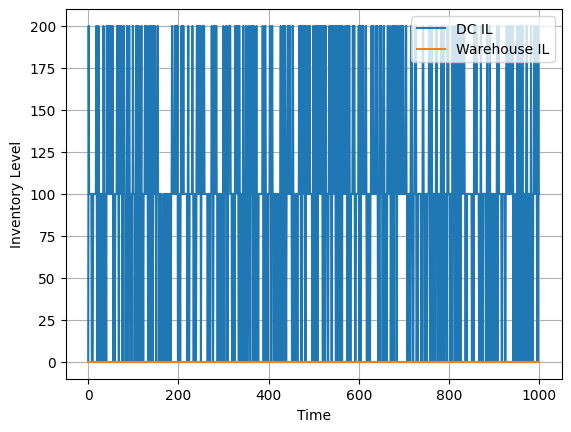

In [3]:
num_periods = 1000
initial_ils = (0, 0)
gamma = 0.999
hs = [1, 0.5]
ps = [50, 25]
demand_dist = {0: 0.2, 100: 0.6, 200: 0.2}
tol = 1e-7
np.random.seed(1234)
c00_simulation_results = simulate_2ech_nolead(num_periods, gamma, initial_ils, hs, ps,
                                              demand_dist, c00_policy, tol)
states_seen, ILs_pre_demand, costs, demands, actions, total_cost = c00_simulation_results

print("Results for centralised system with DC-warehouse ordering constraint")
print(f"Warehouse service level: {sum(states_seen[i][1]+action[1] > 0 for i, action in enumerate(actions))/num_periods*100:.2f}%")
print(f"DC service level: {sum(il[0] > 0 for il in ILs_pre_demand)/num_periods*100:.2f}%")
print(f"Total system costs: {total_cost}")
plt.plot([il[0] for il in states_seen], label="DC IL")
plt.plot([il[1] for il in states_seen], label="Warehouse IL")
plt.xlabel("Time")
plt.ylabel("Inventory Level")
plt.legend()
plt.grid()

### Comparing cost results from simulation with value iteration

Here we compare costs incurred during simulations versus value iteration. We perform 100 runs of the simulation where the length of each simulation is 100 time periods. We use a seed for reproducibility.

In [26]:
# Testing a simulation replication for a centralised system with DWOC for gamma = 0.999
nreps = 100
num_periods = 100
hs = [1, 0.5]
ps = [50, 25]
demand_dist = {0: 0.2, 100: 0.6, 200: 0.2}
lead_times = [0,0]
tol = 1e-7
gamma = 0.999
il0_set = set(int(x) for x in np.linspace(-1000, 1000, 21))
ils_to_check = sorted(set(order_pair for order_pair in itertools.product(il0_set, repeat=2))) 

print("Centralised simulation:")
c00_simulation_costs = simulate_2ech_replications(c00_policy, nreps, num_periods, gamma, 
                           hs, ps, demand_dist, tol, ils_to_check, lead_times, simulate_2ech_constlead)

Centralised simulation:


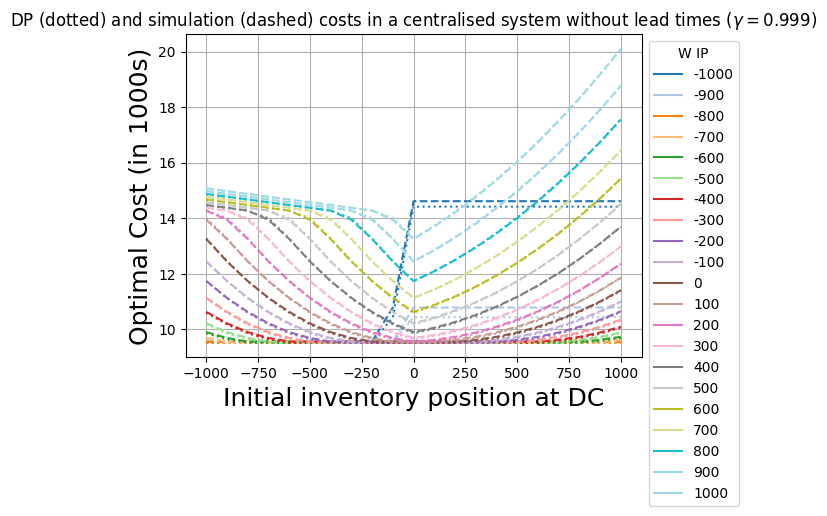

In [27]:
two_cost_plot(c00_simulation_costs, c00_opt_costs, lead_times, 2, title=fr"centralised system without lead times ($\gamma=0.999$)")

## With lead times

In [28]:
c11_results = pickle.load(open(fr'PolicyResults/2ech_c1-1_cap800_MOQ1200_sl98.0_gamma0.999.pkl', "rb"))
c11_policy = c11_results["optimal_policy"]
c11_opt_costs = c11_results["value_function"]

Results for centralised system with DC-warehouse ordering constraint
Warehouse service level: 87.40%
DC service level: 80.70%
Total system costs: 1085972.9860317307


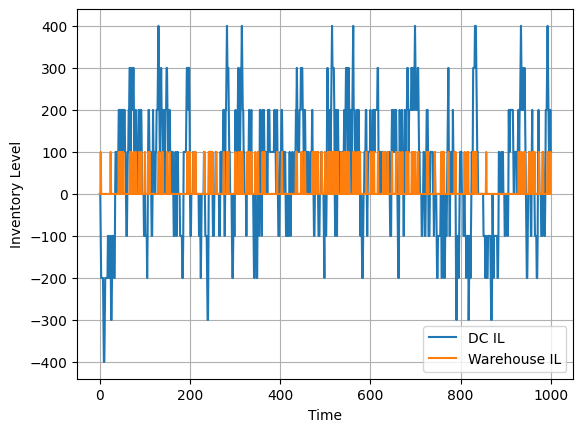

In [29]:
num_periods = 1000
initial_ips = (0, 0, 0, 0)
gamma = 0.999
lead_times = [1, 1]
hs = [1, 0.5]
ps = [50, 25]
demand_dist = {0: 0.2, 100: 0.6, 200: 0.2}
tol = 1e-7
np.random.seed(1234)
c11_simulation_results = simulate_2ech_constlead(num_periods, gamma, initial_ips, hs, ps,
                                              demand_dist, lead_times, c11_policy, tol)
states_seen, ILs_pre_demand, costs, demands, actions, total_cost = c11_simulation_results

print("Results for centralised system with DC-warehouse ordering constraint")
print(f"Warehouse service level: {sum(states_seen[i][1]+action[1] > 0 for i, action in enumerate(actions))/num_periods*100:.2f}%")
print(f"DC service level: {sum(il[0] > 0 for il in ILs_pre_demand)/num_periods*100:.2f}%")
print(f"Total system costs: {total_cost}")
plt.plot([il[0] for il in states_seen], label="DC IL")
plt.plot([il[1] for il in states_seen], label="Warehouse IL")
plt.xlabel("Time")
plt.ylabel("Inventory Level")
plt.legend()
plt.grid()

### Comparing cost results from simulation with value iteration

Here we compare costs incurred during simulations versus value iteration. We perform 100 runs of the simulation where the length of each simulation is 100 time periods. We use a seed for reproducibility.

In [40]:
# Testing a simulation replication for a centralised system with DWOC for gamma = 0.999
nreps = 1
num_periods = 100
hs = [1, 0.5]
ps = [50, 25]
demand_dist = {0: 0.2, 100: 0.6, 200: 0.2}
lead_times = [1, 1]
n_ech = 2
tol = 1e-7
gamma = 0.999
ips0_set = set(int(x) for x in np.linspace(-800, 1200, 21))
ips_to_check = set(itertools.product(ips0_set, repeat=2)) 
states_to_check = sorted(set(state for state in c11_policy.keys() if calculate_ip(state, lead_times, n_ech) in ips_to_check))

print(ips0_set)
print("Centralised simulation:")
c11_simulation_costs = simulate_2ech_replications(c11_policy, nreps, num_periods, gamma, 
                           hs, ps, demand_dist, tol, states_to_check, lead_times, simulate_2ech_constlead)

{0, 900, -500, 400, -100, 800, -600, 300, 1200, -200, 700, -700, 200, 1100, -300, 600, -800, 100, 1000, -400, 500}
Centralised simulation:


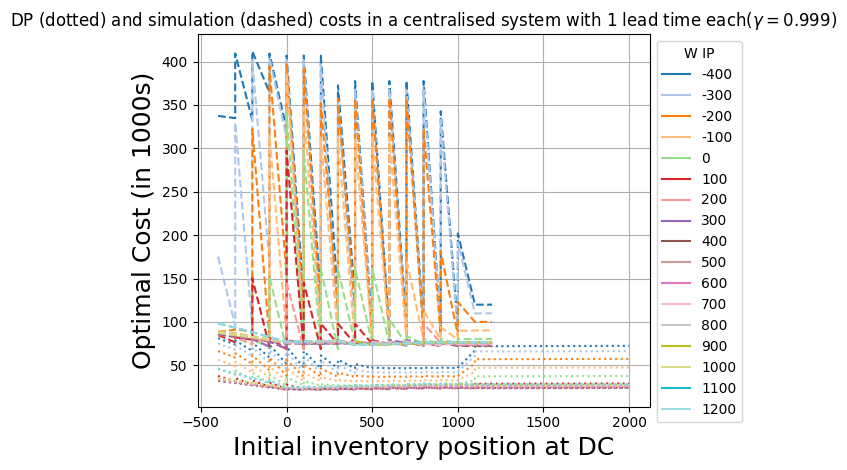

In [41]:
two_cost_plot(c11_simulation_costs, c11_opt_costs, lead_times, n_ech, title=fr"centralised system with 1 lead time each($\gamma=0.999$)")